# Personality Predictor — Introvert vs Extrovert

**Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Preprocessing & Feature Engineering
3. Model Training (Random Forest + Logistic Regression + XGBoost)
4. Evaluation & Metrics
5. Saving the Model for Deployment

---

## Step 1 — Install and Import Libraries

In [1]:
!pip install scikit-learn pandas matplotlib seaborn joblib xgboost -q

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Model persistence
import joblib

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded')

All libraries loaded


## Step 2 — Load the Dataset

In [3]:
# Load the dataset

df = pd.read_csv('personality_dataset.csv')

print(f'Dataset shape : {df.shape}')
print(f'Rows          : {df.shape[0]}')
print(f'Columns       : {df.shape[1]}')
df.head(10)

Dataset shape : (2900, 8)
Rows          : 2900
Columns       : 8


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
5,1.0,No,7.0,5.0,No,6.0,6.0,Extrovert
6,4.0,No,9.0,NaN,No,7.0,7.0,Extrovert
7,2.0,No,8.0,4.0,No,7.0,8.0,Extrovert
8,10.0,Yes,1.0,3.0,Yes,0.0,3.0,Introvert
9,0.0,No,8.0,6.0,No,13.0,8.0,Extrovert


## Step 3 — Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print('=== Data Types ===')
print(df.dtypes)
print()

print('=== Missing Values ===')
print(df.isnull().sum())
print()

print('=== Target Distribution ===')
print(df['Personality'].value_counts())
print()

print(f"Class balance: {df['Personality'].value_counts(normalize=True).round(3).to_dict()}")

=== Data Types ===
Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

=== Missing Values ===
Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

=== Target Distribution ===
Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

Class balance: {'Extrovert': 0.514, 'Introvert': 0.486}


In [5]:
# Numerical summary
df.describe().round(2)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.00,2838.00,2834.00,2823.00,2835.00
mean,4.51,3.96,3.00,6.27,3.56
std,3.48,2.90,2.25,4.29,2.93
min,0.00,0.00,0.00,0.00,0.00
25%,2.00,2.00,1.00,3.00,1.00
50%,4.00,3.00,3.00,5.00,3.00
75%,8.00,6.00,5.00,10.00,6.00
max,11.00,10.00,7.00,15.00,10.00


### EDA Plot 1: Class Distribution and Missing Values

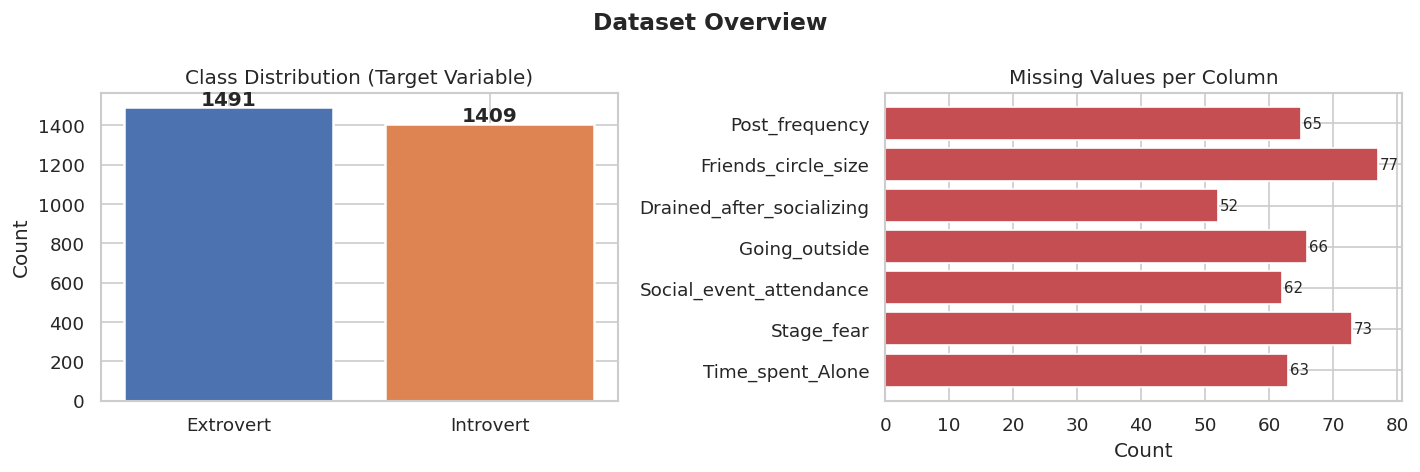

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Class distribution
counts = df['Personality'].value_counts()
colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (Target Variable)')
axes[0].set_ylabel('Count')

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
axes[1].barh(missing.index, missing.values, color='#C44E52', edgecolor='white')
axes[1].set_title('Missing Values per Column')
axes[1].set_xlabel('Count')
for i, v in enumerate(missing.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_overview_1.png', bbox_inches='tight')
plt.show()


##### EDA Plot 1: Checking class balance first — imbalanced data needs special handling This dataset is nearly balanced (51.4% Extrovert vs 48.6% Introvert), so no need for SMOTE or class weighting.

### EDA Plot 2: Feature distributions by Personality

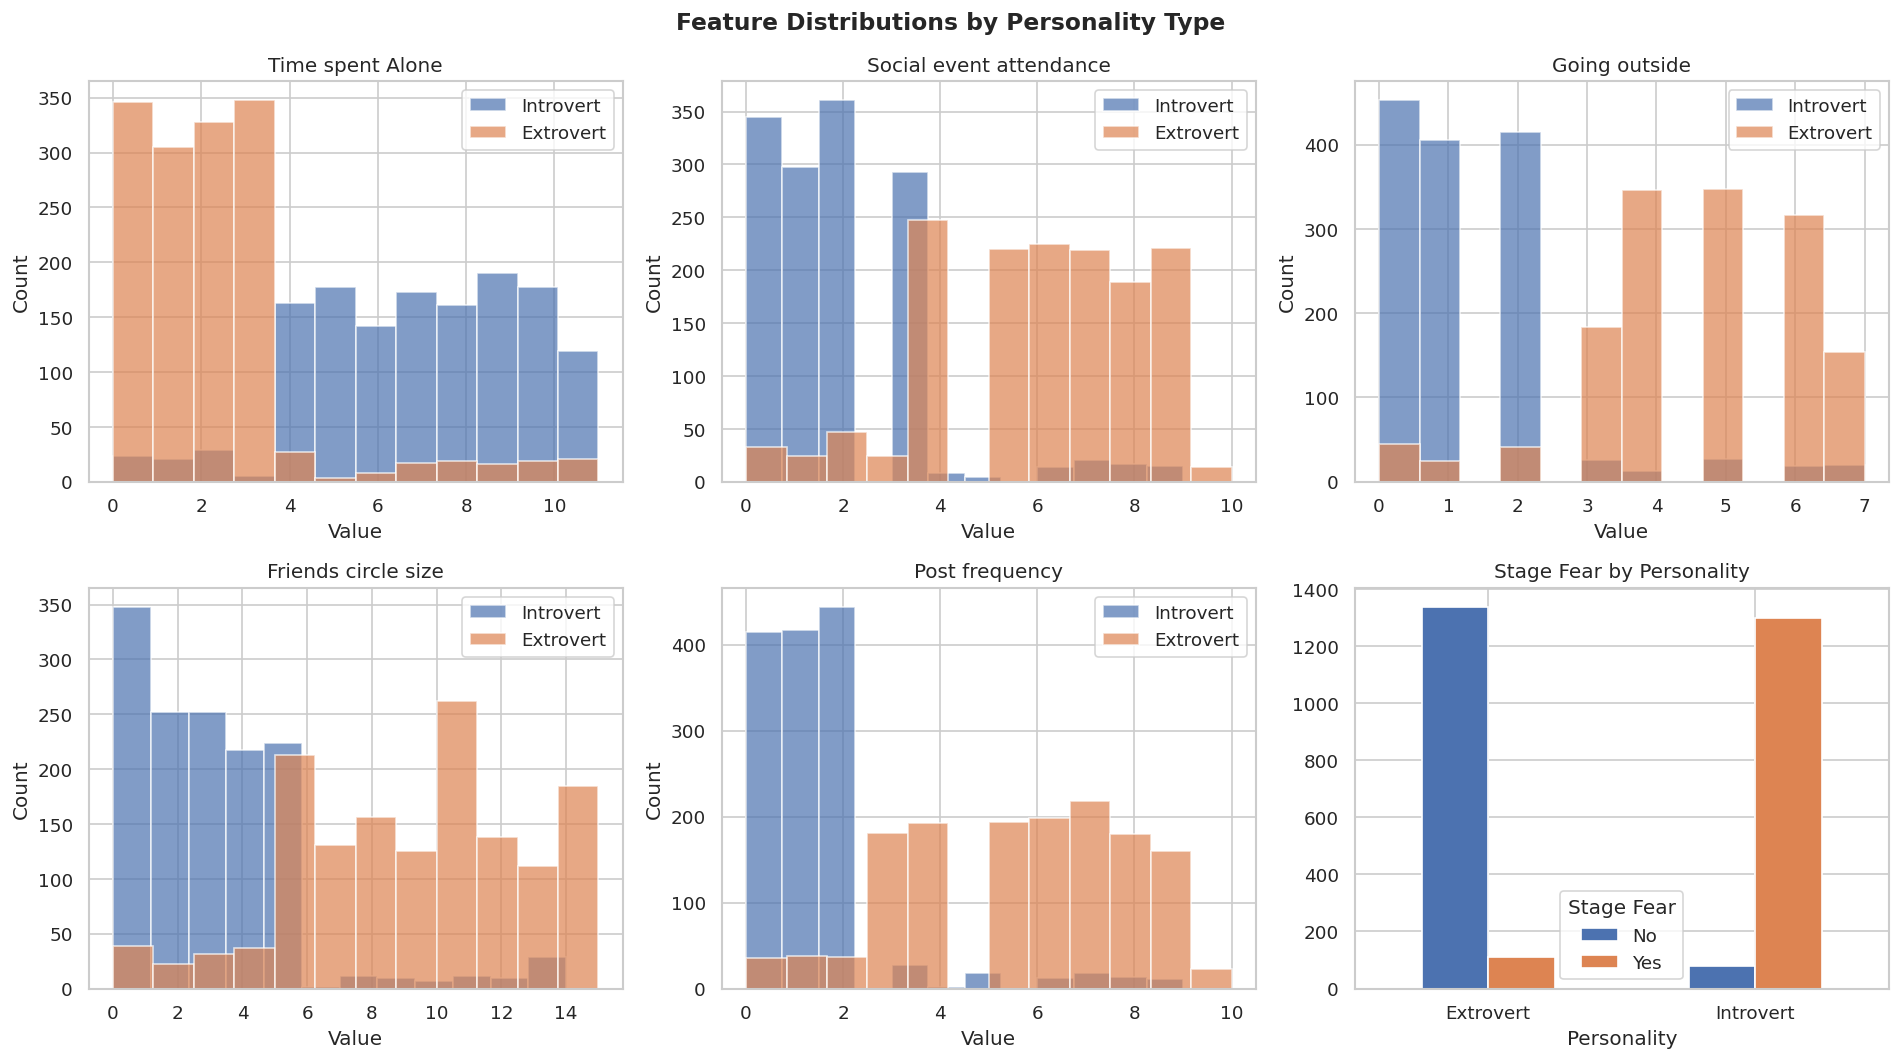

In [7]:
numeric_features = ['Time_spent_Alone', 'Social_event_attendance',
                    'Going_outside', 'Friends_circle_size', 'Post_frequency']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
fig.suptitle('Feature Distributions by Personality Type', fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_features):
    for p, c in zip(['Introvert', 'Extrovert'], ['#4C72B0', '#DD8452']):
        data = df[df['Personality'] == p][col].dropna()
        axes[i].hist(data, alpha=0.7, label=p, color=c, bins=12, edgecolor='white')
    axes[i].set_title(col.replace('_', ' '))
    axes[i].legend()
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

sf = df.groupby(['Personality', 'Stage_fear']).size().unstack(fill_value=0)
sf.plot(kind='bar', ax=axes[5], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[5].set_title('Stage Fear by Personality')
axes[5].set_xticklabels(axes[5].get_xticklabels(), rotation=0)
axes[5].legend(title='Stage Fear')

plt.tight_layout()
plt.savefig('eda_overview_2.png', bbox_inches='tight')
plt.show()

##### EDA Plot 2: Visualizing each feature split by personality confirms which features are strong predictors. Clear separation (e.g. Time_spent_Alone peaks far apart for Introvert vs Extrovert) means the model has a strong signal to learn from. Overlapping distributions = weaker feature.

### EDA Plot 3: Correlation heatmap (after encoding)

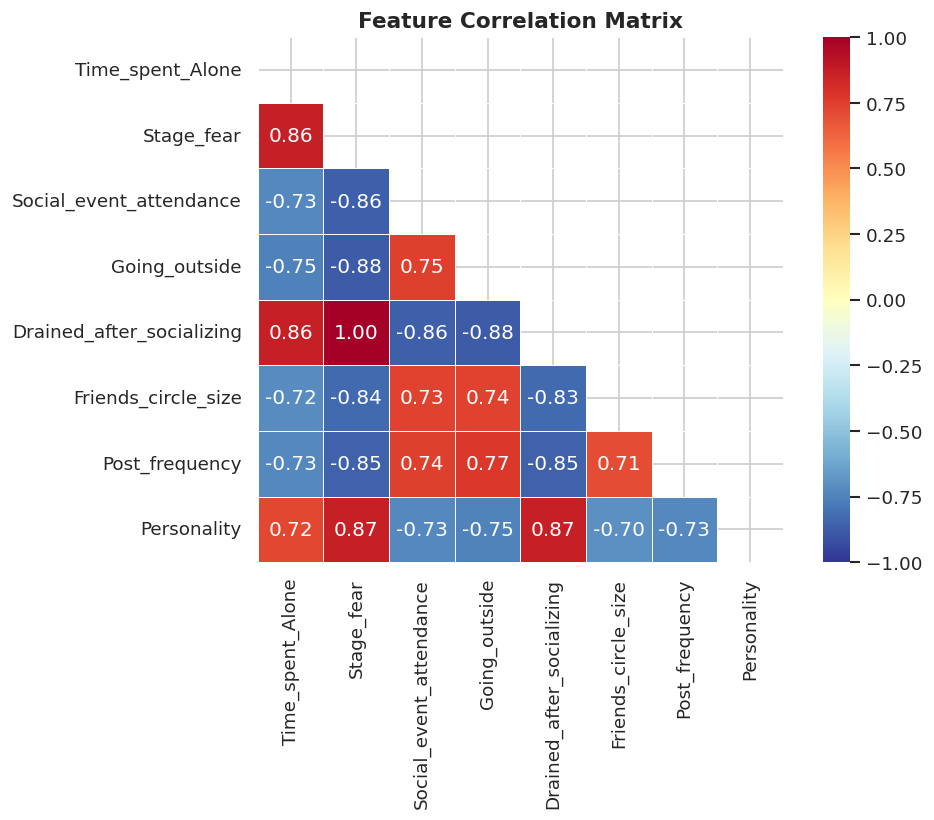

In [8]:
df_corr = df.copy()
df_corr['Stage_fear'] = df_corr['Stage_fear'].map({'Yes': 1, 'No': 0})
df_corr['Drained_after_socializing'] = df_corr['Drained_after_socializing'].map({'Yes': 1, 'No': 0})
df_corr['Personality'] = df_corr['Personality'].map({'Introvert': 1, 'Extrovert': 0})

corr_matrix = df_corr.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()


##### EDA Plot 3: Correlation helps identify
1. Features most predictive of the target
2. Multicollinearity (high correlation between features)

Random Forest handles multicollinearity well, so no feature removal needed.

## Step 4 — Preprocessing

In [9]:
df_model = df.copy()

# Define column groups
yes_no_cols  = ['Stage_fear', 'Drained_after_socializing']
numeric_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
                'Friends_circle_size', 'Post_frequency']
feature_cols = numeric_cols + yes_no_cols
target_col   = 'Personality'

# Encode binary categorical features
for col in yes_no_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

# Compute fill values for missing data
fill_values = {}
for col in numeric_cols:
    fill_values[col] = float(df_model[col].median())
for col in yes_no_cols:
    fill_values[col] = float(df_model[col].mode()[0])

print('Fill values used for imputation:')
for k, v in fill_values.items():
    print(f'  {k}: {v}')

# Apply imputation
for col, val in fill_values.items():
    df_model[col] = df_model[col].fillna(val)

print(f'\nRemaining NaN values: {df_model[feature_cols].isnull().sum().sum()}')

# Encode target variable
df_model[target_col] = df_model[target_col].map({'Introvert': 1, 'Extrovert': 0})

print(f'\nTarget encoding: Introvert=1, Extrovert=0')
print(f'Target distribution after encoding:\n{df_model[target_col].value_counts()}')

Fill values used for imputation:
  Time_spent_Alone: 4.0
  Social_event_attendance: 3.0
  Going_outside: 3.0
  Friends_circle_size: 5.0
  Post_frequency: 3.0
  Stage_fear: 0.0
  Drained_after_socializing: 0.0

Remaining NaN values: 0

Target encoding: Introvert=1, Extrovert=0
Target distribution after encoding:
Personality
0    1491
1    1409
Name: count, dtype: int64


## Step 5 — Train/Test Split

In [10]:
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set   : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set       : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain class distribution:\n{y_train.value_counts()}')
print(f'\nTest class distribution:\n{y_test.value_counts()}')

Training set   : 2320 rows (80.0%)
Test set       : 580 rows (20.0%)

Train class distribution:
Personality
0    1193
1    1127
Name: count, dtype: int64

Test class distribution:
Personality
0    298
1    282
Name: count, dtype: int64


## Step 6 — Model Training

###Model 1: Random Forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_train_preds = rf_model.predict(X_train)
rf_preds       = rf_model.predict(X_test)

rf_train_acc   = accuracy_score(y_train, rf_train_preds)
rf_acc         = accuracy_score(y_test,  rf_preds)

rf_cv = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print('=== Random Forest Results ===')
print(f'Training Accuracy : {rf_train_acc:.4f} ({rf_train_acc*100:.2f}%)')
print(f'Testing  Accuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'CV Mean  (5-fold) : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print()

# Overfit / Underfit Diagnosis
gap = rf_train_acc - rf_acc
if gap > 0.05:
    print(f'Overfit detected  — Train/Test gap: {gap*100:.2f}%')
elif rf_acc < 0.75:
    print(f'Underfit detected — Test Accuracy too low: {rf_acc*100:.2f}%')
else:
    print(f'Good fit          — Train/Test gap: {gap*100:.2f}%')

print()
print('Classification Report:')
print(classification_report(y_test, rf_preds, target_names=['Extrovert', 'Introvert']))

=== Random Forest Results ===
Training Accuracy : 0.9435 (94.35%)
Testing  Accuracy : 0.9155 (91.55%)
CV Mean  (5-fold) : 0.9303 ± 0.0158

Good fit          — Train/Test gap: 2.80%

Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.94      0.89      0.92       298
   Introvert       0.89      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



### Model 2: Logistic Regression


In [12]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

lr_train_preds = lr_pipeline.predict(X_train)
lr_preds       = lr_pipeline.predict(X_test)

lr_train_acc   = accuracy_score(y_train, lr_train_preds)
lr_acc         = accuracy_score(y_test,  lr_preds)

print('=== Logistic Regression Results ===')
print(f'Training Accuracy : {lr_train_acc:.4f} ({lr_train_acc*100:.2f}%)')
print(f'Testing  Accuracy : {lr_acc:.4f} ({lr_acc*100:.2f}%)')
print()

# Overfit / Underfit Diagnosis
gap = lr_train_acc - lr_acc
if gap > 0.05:
    print(f'Overfit detected  — Train/Test gap: {gap*100:.2f}%')
elif lr_acc < 0.75:
    print(f'Underfit detected — Test Accuracy too low: {lr_acc*100:.2f}%')
else:
    print(f'Good fit          — Train/Test gap: {gap*100:.2f}%')

print()
print('Classification Report:')
print(classification_report(y_test, lr_preds, target_names=['Extrovert', 'Introvert']))

=== Logistic Regression Results ===
Training Accuracy : 0.9319 (93.19%)
Testing  Accuracy : 0.9052 (90.52%)

Good fit          — Train/Test gap: 2.67%

Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.92      0.90      0.91       298
   Introvert       0.89      0.91      0.90       282

    accuracy                           0.91       580
   macro avg       0.91      0.91      0.91       580
weighted avg       0.91      0.91      0.91       580



### Model 3: XGBoost

In [13]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_train_preds = xgb_model.predict(X_train)
xgb_preds       = xgb_model.predict(X_test)

xgb_train_acc   = accuracy_score(y_train, xgb_train_preds)
xgb_acc         = accuracy_score(y_test,  xgb_preds)

xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

print('=== XGBoost Results ===')
print(f'Training Accuracy : {xgb_train_acc:.4f} ({xgb_train_acc*100:.2f}%)')
print(f'Testing  Accuracy : {xgb_acc:.4f} ({xgb_acc*100:.2f}%)')
print(f'CV Mean  (5-fold) : {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')
print()

# Overfit / Underfit Diagnosis
gap = xgb_train_acc - xgb_acc
if gap > 0.05:
    print(f'Overfit detected  — Train/Test gap: {gap*100:.2f}%')
elif xgb_acc < 0.75:
    print(f'Underfit detected — Test Accuracy too low: {xgb_acc*100:.2f}%')
else:
    print(f'Good fit          — Train/Test gap: {gap*100:.2f}%')

print()
print('Classification Report:')
print(classification_report(y_test, xgb_preds, target_names=['Extrovert', 'Introvert']))

=== XGBoost Results ===
Training Accuracy : 0.9431 (94.31%)
Testing  Accuracy : 0.9155 (91.55%)
CV Mean  (5-fold) : 0.9272 ± 0.0122

Good fit          — Train/Test gap: 2.76%

Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.89      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



In [14]:
# Full model comparison: Train vs Test + gap diagnosis
comparison = pd.DataFrame({
    'Model'         : ['Random Forest', 'Logistic Regression', 'XGBoost'],
    'Train Acc'     : [f'{rf_train_acc*100:.2f}%',  f'{lr_train_acc*100:.2f}%',  f'{xgb_train_acc*100:.2f}%'],
    'Test  Acc'     : [f'{rf_acc*100:.2f}%',         f'{lr_acc*100:.2f}%',         f'{xgb_acc*100:.2f}%'],
    'Gap'           : [
        f'{(rf_train_acc  - rf_acc)*100:.2f}%',
        f'{(lr_train_acc  - lr_acc)*100:.2f}%',
        f'{(xgb_train_acc - xgb_acc)*100:.2f}%'
    ],
    'Precision'     : [
        f'{precision_score(y_test, rf_preds)*100:.2f}%',
        f'{precision_score(y_test, lr_preds)*100:.2f}%',
        f'{precision_score(y_test, xgb_preds)*100:.2f}%'
    ],
    'Recall'        : [
        f'{recall_score(y_test, rf_preds)*100:.2f}%',
        f'{recall_score(y_test, lr_preds)*100:.2f}%',
        f'{recall_score(y_test, xgb_preds)*100:.2f}%'
    ],
    'F1 Score'      : [
        f'{f1_score(y_test, rf_preds)*100:.2f}%',
        f'{f1_score(y_test, lr_preds)*100:.2f}%',
        f'{f1_score(y_test, xgb_preds)*100:.2f}%'
    ],
    'Fit Status'    : [
        'Good' if abs(rf_train_acc  - rf_acc)  <= 0.05 else 'Overfit',
        'Good' if abs(lr_train_acc  - lr_acc)  <= 0.05 else 'Overfit',
        'Good' if abs(xgb_train_acc - xgb_acc) <= 0.05 else 'Overfit',
    ]
})

print(comparison.to_string(index=False))

              Model Train Acc Test  Acc   Gap Precision Recall F1 Score Fit Status
      Random Forest    94.35%    91.55% 2.80%    89.23% 93.97%   91.54%       Good
Logistic Regression    93.19%    90.52% 2.67%    89.27% 91.49%   90.37%       Good
            XGBoost    94.31%    91.55% 2.76%    89.49% 93.62%   91.51%       Good


## Step 7 — Evaluation & Visualizations

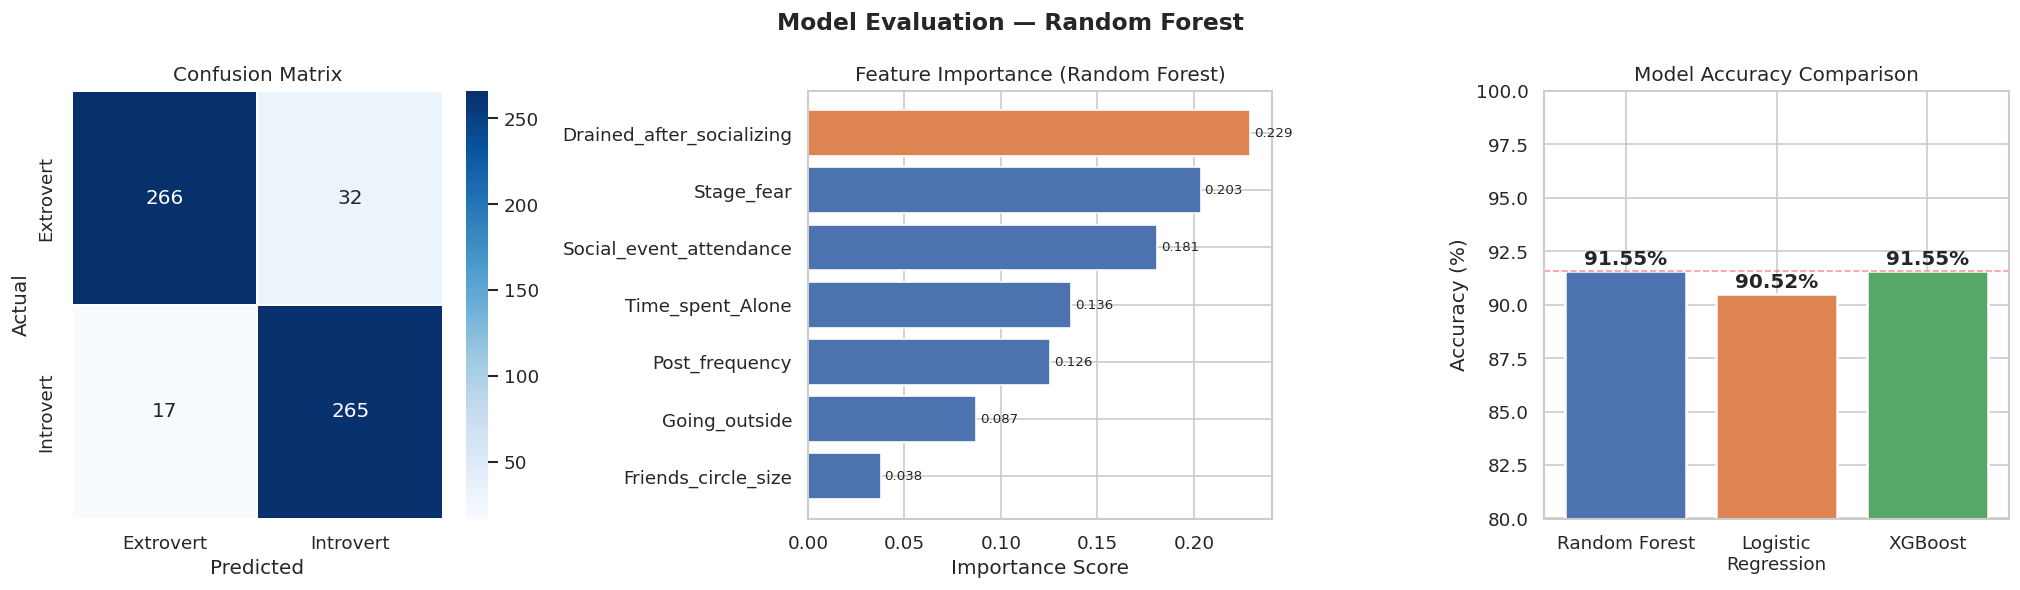

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Model Evaluation — Random Forest', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Extrovert', 'Introvert'],
            yticklabels=['Extrovert', 'Introvert'],
            linewidths=1)
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature Importance
fi = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
color_list = ['#4C72B0'] * len(fi)
color_list[-1] = '#DD8452'  # highlight most important feature
axes[1].barh(fi.index, fi.values, color=color_list, edgecolor='white')
axes[1].set_title('Feature Importance (Random Forest)')
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(fi.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

# Model Comparison Bar
model_names = ['Random Forest', 'Logistic\nRegression', 'XGBoost']
accuracies  = [rf_acc * 100,    lr_acc * 100,           xgb_acc * 100]
bar_colors  = ['#4C72B0',       '#DD8452',               '#55A868']

bars = axes[2].bar(model_names, accuracies, color=bar_colors,
                   edgecolor='white', linewidth=1.5)
for bar, a in zip(bars, accuracies):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{a:.2f}%', ha='center', fontweight='bold')
axes[2].set_ylim(80, 100)
axes[2].set_title('Model Accuracy Comparison')
axes[2].set_ylabel('Accuracy (%)')
axes[2].axhline(y=max(rf_acc, xgb_acc)*100, color='red',
                linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()

In [16]:
# Feature Importance Analysis
fi_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'RF_Importance' : rf_model.feature_importances_,
    'XGB_Importance': xgb_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

fi_df['RF_Importance %']  = (fi_df['RF_Importance']  * 100).round(2).astype(str) + '%'
fi_df['XGB_Importance %'] = (fi_df['XGB_Importance'] * 100).round(2).astype(str) + '%'

print('Feature Importance Ranking (RF vs XGBoost):')
print(fi_df[['Feature', 'RF_Importance %', 'XGB_Importance %']].to_string(index=False))

Feature Importance Ranking (RF vs XGBoost):
                  Feature RF_Importance % XGB_Importance %
Drained_after_socializing          22.92%           97.36%
               Stage_fear          20.35%            0.32%
  Social_event_attendance          18.08%            0.41%
         Time_spent_Alone          13.62%            0.36%
           Post_frequency          12.55%            0.83%
            Going_outside            8.7%            0.35%
      Friends_circle_size           3.77%            0.37%


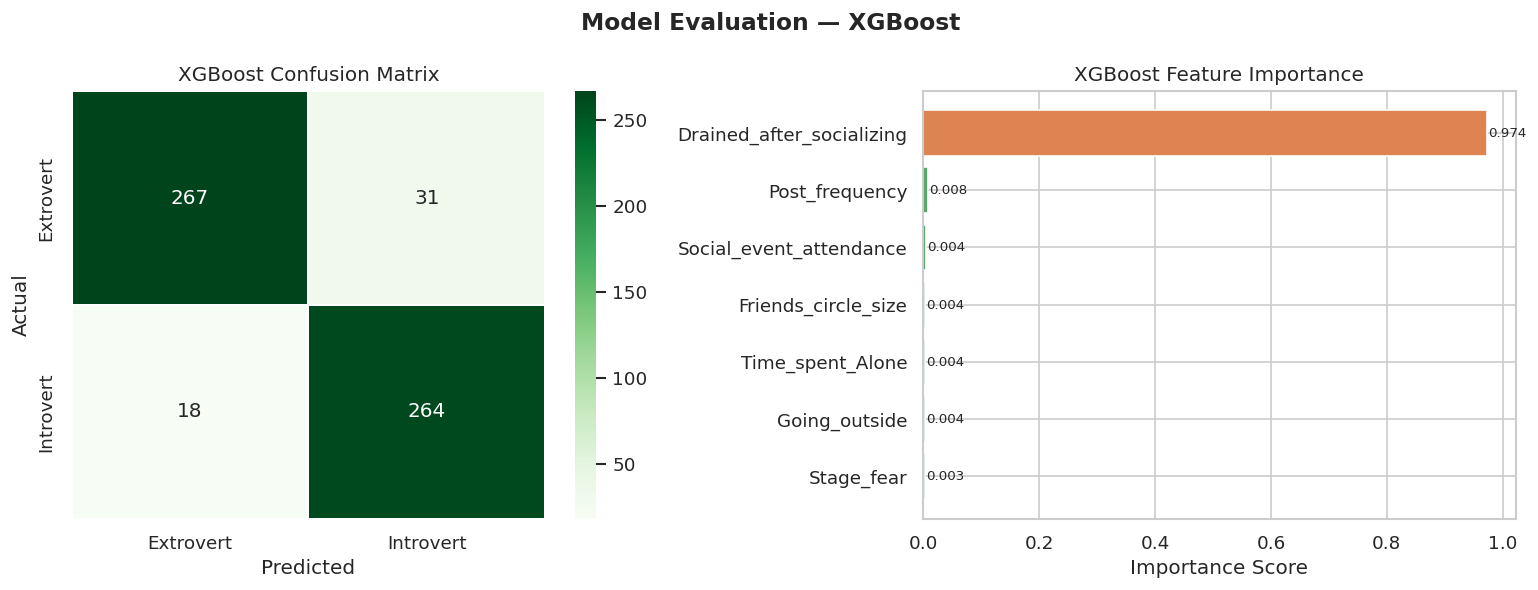

In [17]:
# XGBoost Evaluation Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation — XGBoost', fontsize=14, fontweight='bold')

# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Extrovert', 'Introvert'],
            yticklabels=['Extrovert', 'Introvert'],
            linewidths=1)
axes[0].set_title('XGBoost Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# XGBoost Feature Importance
fi_xgb = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
color_list_xgb = ['#55A868'] * len(fi_xgb)
color_list_xgb[-1] = '#DD8452'  # highlight most important feature
axes[1].barh(fi_xgb.index, fi_xgb.values, color=color_list_xgb, edgecolor='white')
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(fi_xgb.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('xgb_evaluation.png', bbox_inches='tight')
plt.show()

## Step 8 — Save Model Artifact

In [18]:
# Determine best model
best_name, best_model, best_preds, best_acc = max(
    [('RandomForest', rf_model, rf_preds, rf_acc),
     ('XGBoost',      xgb_model, xgb_preds, xgb_acc)],
    key=lambda x: x[3]
)

model_artifact = {
    'model'           : best_model,
    'feature_columns' : feature_cols,
    'label_map'       : {0: 'Extrovert', 1: 'Introvert'},
    'fill_values'     : fill_values,
    'yes_no_cols'     : yes_no_cols,
    'numeric_cols'    : numeric_cols,
    'model_accuracy'  : round(best_acc, 4),
    'cv_mean'         : round(rf_cv.mean(), 4),
    'precision'       : round(precision_score(y_test, best_preds), 4),
    'recall'          : round(recall_score(y_test, best_preds), 4),
    'f1_score'        : round(f1_score(y_test, best_preds), 4),
}

joblib.dump(model_artifact, 'model/personality_model.joblib')
print(f'Best model: {best_name} | Accuracy: {best_acc*100:.2f}% | '
      f'Precision: {model_artifact["precision"]:.4f} | '
      f'Recall: {model_artifact["recall"]:.4f} | '
      f'F1: {model_artifact["f1_score"]:.4f}')

Best model: RandomForest | Accuracy: 91.55% | Precision: 0.8923 | Recall: 0.9397 | F1: 0.9154


In [19]:
import os
os.makedirs('model', exist_ok=True)

# Pack everything the API needs into one artifact

model_artifact = {
    # trained Random Forest model
    'model'           : rf_model,

    # Feature column names in the exact order the model expects
    'feature_columns' : feature_cols,

    # Label decoder: model outputs 0 or 1, API returns 'Extrovert' or 'Introvert'
    'label_map'       : {0: 'Extrovert', 1: 'Introvert'},

    # Imputation values — same values used during training
    'fill_values'     : fill_values,

    # Column type groups for preprocessing in the API
    'yes_no_cols'     : yes_no_cols,
    'numeric_cols'    : numeric_cols,

    # Model performance metrics
    'model_accuracy'  : round(rf_acc, 4),
    'cv_mean'         : round(rf_cv.mean(), 4),
}


joblib.dump(model_artifact, 'model/personality_model.joblib')

print('Model artifact saved to: model/personality_model.joblib')
print()
print('=== Model Summary ===')
print(f'Algorithm     : Random Forest Classifier')
print(f'Trees         : 200')
print(f'Test Accuracy : {rf_acc*100:.2f}%')
print(f'CV Mean       : {rf_cv.mean()*100:.2f}%')
print(f'CV Std        : ±{rf_cv.std()*100:.2f}%')
print(f'Features      : {len(feature_cols)}')
print(f'Training rows : {len(X_train)}')
print()

Model artifact saved to: model/personality_model.joblib

=== Model Summary ===
Algorithm     : Random Forest Classifier
Trees         : 200
Test Accuracy : 91.55%
CV Mean       : 93.03%
CV Std        : ±1.58%
Features      : 7
Training rows : 2320



## Step 9 — Test the saved model

In [20]:
artifact = joblib.load('model/personality_model.joblib')

def predict_personality(input_data: dict, artifact: dict) -> str:
    """
    Replicates what the FastAPI endpoint will do.
    input_data: raw dict from user (may have missing keys)
    artifact: loaded joblib artifact
    returns: 'Introvert' or 'Extrovert'
    """
    model     = artifact['model']
    feat_cols = artifact['feature_columns']
    fills     = artifact['fill_values']
    label_map = artifact['label_map']

    row = {}
    for col in feat_cols:
        val = input_data.get(col, None)
        if col in artifact['yes_no_cols']:
            val = 1.0 if str(val).lower() in ['yes', '1', 'true'] else (
                  0.0 if str(val).lower() in ['no',  '0', 'false'] else fills[col])
        else:
            val = float(val) if val is not None else fills[col]
        row[col] = val

    df_input = pd.DataFrame([row])[feat_cols]
    prediction = model.predict(df_input)[0]
    return label_map[int(prediction)]

# Test case 1 — clear introvert
introvert_input = {
    'Time_spent_Alone'         : 9.0,
    'Stage_fear'               : 'Yes',
    'Social_event_attendance'  : 1.0,
    'Going_outside'            : 1.0,
    'Drained_after_socializing': 'Yes',
    'Friends_circle_size'      : 2.0,
    'Post_frequency'           : 1.0,
}

# Test case 2 — clear extrovert
extrovert_input = {
    'Time_spent_Alone'         : 1.0,
    'Stage_fear'               : 'No',
    'Social_event_attendance'  : 9.0,
    'Going_outside'            : 8.0,
    'Drained_after_socializing': 'No',
    'Friends_circle_size'      : 14.0,
    'Post_frequency'           : 8.0,
}

print('Sanity Check Results:')
print(f'  Introvert test → {predict_personality(introvert_input, artifact)}')
print(f'  Extrovert test → {predict_personality(extrovert_input, artifact)}')
print()
print('Model artifact is working correctly')

Sanity Check Results:
  Introvert test → Introvert
  Extrovert test → Extrovert

Model artifact is working correctly
